In [1]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [2]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [9]:
(df.isnull().sum() / len(df)) * 100

,0
show_id,0.000000
type,0.000000
title,0.000000
director,29.908028
cast,9.367549
country,9.435676
date_added,0.113546
release_year,0.000000
rating,0.045418
duration,0.034064


In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

In [14]:
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [15]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [16]:
df['duration'] = df['duration'].fillna('Unknown')

In [17]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [19]:
# Convert date_added to datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Create new features
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day

# Extract movie duration in minutes (for movies only)
df['duration_num'] = df['duration'].str.extract('(\d+)')
df['duration_num'] = pd.to_numeric(df['duration_num'], errors='coerce')

# Verify new columns
df[['date_added', 'year_added', 'month_added', 'day_added', 'duration_num']].head()

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_624/2792331667.py:10: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)')


,date_added,year_added,month_added,day_added,duration_num
0,2021-09-25,2021.0,9.0,25.0,90.0
1,2021-09-24,2021.0,9.0,24.0,2.0
2,2021-09-24,2021.0,9.0,24.0,1.0
3,2021-09-24,2021.0,9.0,24.0,1.0
4,2021-09-24,2021.0,9.0,24.0,2.0


In [21]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


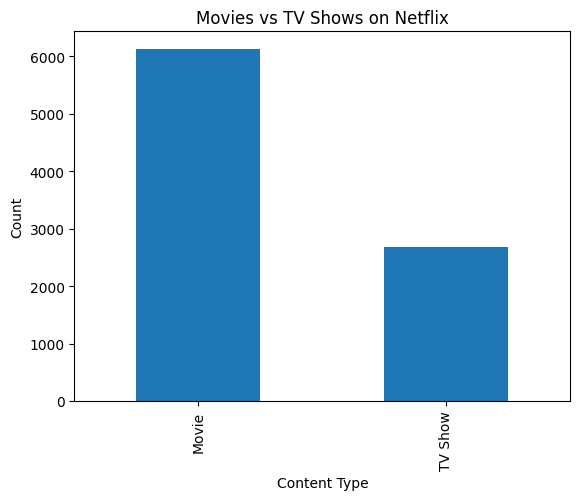

In [23]:
import matplotlib.pyplot as plt
df['type'].value_counts().plot(kind='bar')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

In [24]:
top_countries = df['country'].value_counts().head(10)

top_countries

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


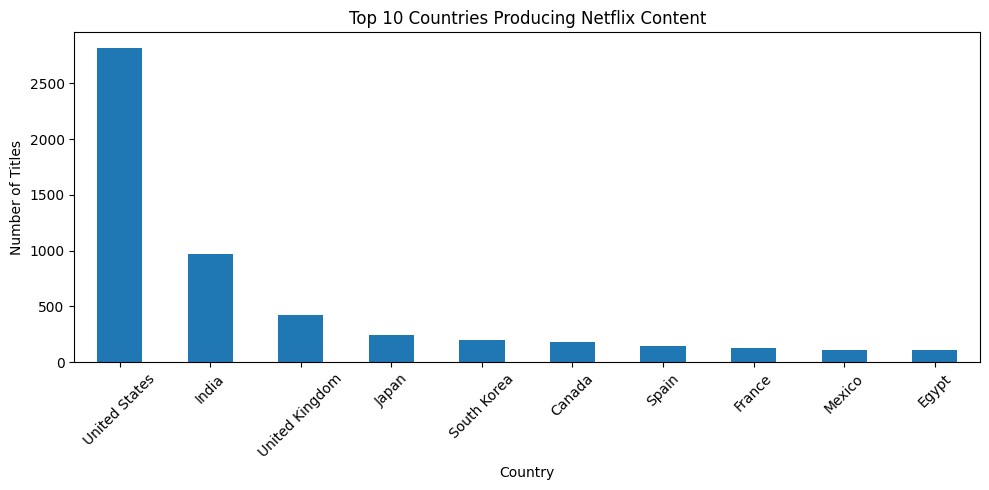

In [33]:
country_df = df[df['country'] != 'Unknown']

top_countries = country_df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [26]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


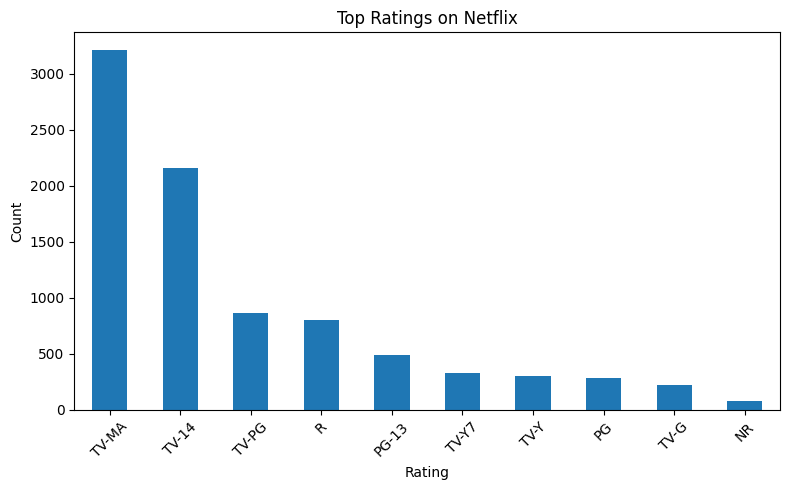

In [27]:
plt.figure(figsize=(8,5))

df['rating'].value_counts().head(10).plot(kind='bar')

plt.title('Top Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [28]:
content_by_year = df['year_added'].value_counts().sort_index()

content_by_year

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


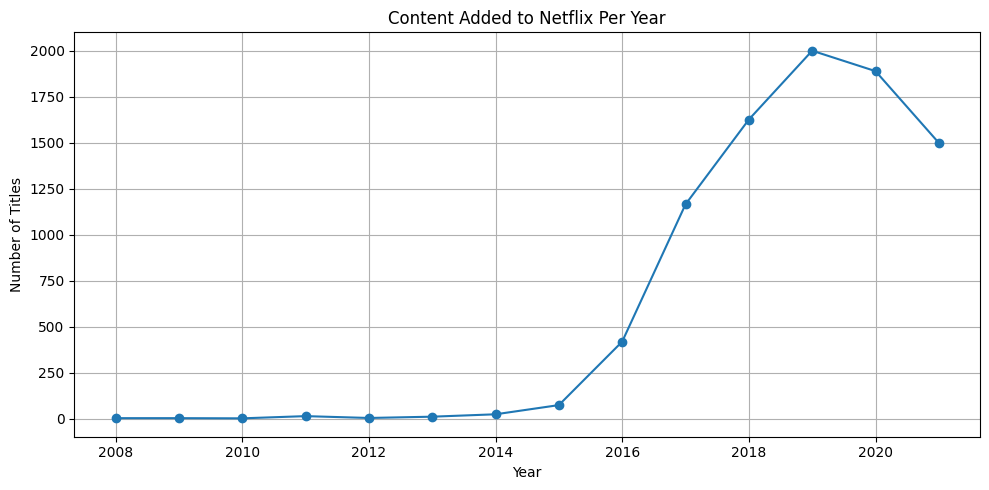

In [29]:
plt.figure(figsize=(10,5))

content_by_year.plot(kind='line', marker='o')

plt.title('Content Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True)
plt.tight_layout()

plt.show()

In [30]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


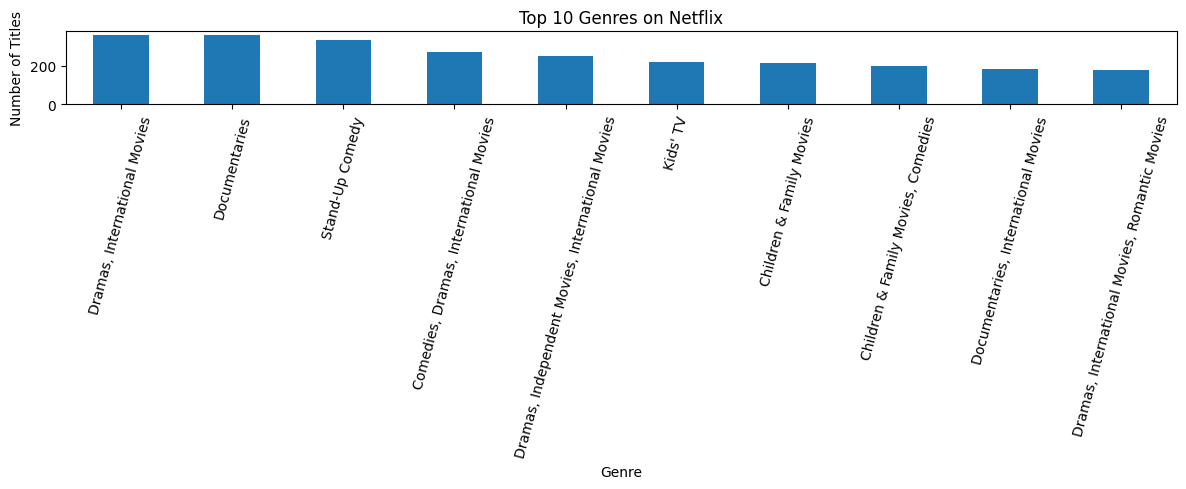

In [31]:
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,5))

top_genres.plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

# Key Findings

1. Movies significantly outnumber TV Shows on Netflix.
2. The United States contributes the highest amount of content, followed by India.
3. TV-MA and TV-14 are the most common ratings, indicating a focus on mature and teenage audiences.
4. Netflix experienced rapid content growth between 2016 and 2019.
5. Content additions reached their peak in 2019.
6. Drama, Documentaries, and Stand-Up Comedy are among the most popular genres.
7. Content production is concentrated among a few major countries.